In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

# Load

In [12]:
periodo = 2

if periodo == 1:
    datasets = ['BDAP_periodo1', 'BDAP_anticipazioni_periodo1', 'anticipazioni_periodo1', 'BDAP_anticipazioni_new_periodo1']
    names = ['BDAP', 'BDAP + Anticipazioni', 'Anticipazioni', 'Ready BDAP + Anticipazioni']
else:
    datasets = ['BDAP_periodo2', 'BDAP_anticipazioni_periodo2', 'anticipazioni_periodo2', 'indicatori_periodo2','indicatori_anticipazioni_periodo2', 'BDAP_indicatori_anticipazioni_periodo2', 'BDAP_anticipazioni_new_periodo2']
    names = ['BDAP', 'BDAP + Anticipazioni', 'Anticipazioni', 'Indicatori', 'Indicatori + Anticipazioni', 'BDAP + Indicatori + Anticipazioni', 'Ready BDAP + Anticipazioni']

results = {}

for dataset in datasets:
    results[dataset] = {}
    # path = f'results/results_{dataset}.pickle'
    path = f'rss/results/results_{dataset}.pickle'
    temp = pickle.load(open(path, 'rb'))
    for pred, elem1 in temp.items():
        results[dataset][pred] = {}
        for lag, elem2 in elem1.items():
            results[dataset][pred][lag] = {}
            for model, elem3 in elem2.items():
                results[dataset][pred][lag][model] = elem3

In [13]:
points = []
labels = []
for name, result in results.items():
    name = names[datasets.index(name)]
    for pred, elem in result.items():
        for lag, elem2 in elem.items():
            for model, elem3 in elem2.items():
                points.append((elem3['roc_auc_test'], elem3['pr_auc_test'], elem3['precision_test'], elem3['recall_test']))
                labels.append((name, lag, pred, model))

roc = [elem[0] for elem in points]
pr = [elem[1] for elem in points]
precision = [elem[2] for elem in points]
recall = [elem[3] for elem in points]
f1 = [2 * (p * r) / (p + r) if (p + r) > 0 else 0 for p, r in zip(precision, recall)]

In [5]:
labels_t = []
pr_t = []
for elem1, elem2 in zip(labels, pr):
    if elem1[3] == 'Random Forest':
        labels_t.append(elem1)
        pr_t.append(elem2)

f1_t = []
for elem1, elem2 in zip(labels, f1):
    if elem1[3] == 'Random Forest':
        labels_t.append(elem1)
        f1_t.append(elem2)

In [6]:
t = labels_t[np.argmax(f1_t)]
t = labels[np.argmax(f1)]
name = datasets[names.index(t[0])]

In [7]:
t

('BDAP + Anticipazioni', 6, 3, 'Random Forest')

In [8]:
temp = results[name][t[2]][t[1]][t[3]]
print(f"{temp['precision_test']:.3f}", f"{temp['recall_test']:.3f}", f"{temp['f1_test']:.3f}")
# print(f"{np.mean(precision):.3f}", f"{np.mean(recall):.3f}", f"{np.mean(f1):.3f}")

0.344 0.272 0.303


# Tables

In [14]:
name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

df = pd.DataFrame({
    'name': name,
    'pred': pred,
    'lag': lag,
    'model': model,
    'roc': roc,
    'pr': pr
})

# Summary functions
def summarize_metric(metric_series):
    return pd.Series({
        'min': metric_series.min(),
        'p5': np.percentile(metric_series, 5),
        'p25': np.percentile(metric_series, 25),
        'p50': np.percentile(metric_series, 50),
        'p75': np.percentile(metric_series, 75),
        'p95': np.percentile(metric_series, 95),
        'max': metric_series.max(),
        'mean': metric_series.mean(),
        'std': metric_series.std()
    })

grouping_keys = ['model', 'pred', 'lag', 'name']

summary_roc_dfs = {}
summary_pr_dfs = {}

for key in grouping_keys:
    roc_rows = []
    pr_rows = []
    grouped = df.groupby(key)

    for group_value, group_df in grouped:
        label = str(group_value)

        roc_stats = summarize_metric(group_df['roc'])
        pr_stats = summarize_metric(group_df['pr'])

        roc_stats[key] = label
        pr_stats[key] = label

        roc_rows.append(roc_stats)
        pr_rows.append(pr_stats)
    summary_roc = pd.DataFrame(roc_rows).set_index(key).sort_index()
    summary_pr = pd.DataFrame(pr_rows).set_index(key).sort_index()
    summary_roc = summary_roc.round(3)
    summary_pr = summary_pr.round(3)

    summary_roc_dfs[f"summary_roc_by_{key}"] = summary_roc
    summary_pr_dfs[f"summary_pr_by_{key}"] = summary_pr

    print(f"\n=== ROC Summary by {key.upper()} ===")
    print(summary_roc)
    
    print(f"\n=== PR Summary by {key.upper()} ===")
    print(summary_pr)




=== ROC Summary by MODEL ===
                       min     p5    p25    p50    p75    p95    max   mean  \
model                                                                         
CNN                  0.482  0.528  0.764  0.824  0.874  0.901  0.908  0.791   
Decision Tree        0.249  0.281  0.507  0.527  0.552  0.568  0.585  0.498   
GNN                  0.580  0.633  0.700  0.733  0.764  0.831  0.882  0.731   
Logistic Regression  0.697  0.748  0.799  0.863  0.889  0.928  0.934  0.851   
Random Forest        0.255  0.280  0.853  0.879  0.904  0.939  0.946  0.793   
XGBoost              0.339  0.597  0.792  0.835  0.872  0.897  0.912  0.808   

                       std  
model                       
CNN                  0.111  
Decision Tree        0.092  
GNN                  0.062  
Logistic Regression  0.059  
Random Forest        0.223  
XGBoost              0.108  

=== PR Summary by MODEL ===
                       min     p5    p25    p50    p75    p95    max   mean 

In [15]:
with open(f"tables_periodo{periodo}.tex", "w") as f:
    
    for key, df1 in summary_roc_dfs.items():
        df1 = df1.round(3)
        f.write(f"% Summary ROC for {key}\n")
        f.write(df1.to_latex(index=True, caption=f"ROC AUC Summary by {key}",float_format="%.3f".__mod__, label=f"tab:roc_{key}"))

    for key, df1 in summary_pr_dfs.items():
        df1 = df1.round(3)
        f.write(f"% Summary PR for {key}\n")
        f.write(df1.to_latex(index=True, caption=f"PR AUC Summary by {key}",float_format="%.3f".__mod__, label=f"tab:pr_{key}"))

In [16]:
# Median AUC tables: models as rows, datasets as columns
roc_median_pivot = pd.pivot_table(
    df, index='model', columns='name', values='roc', aggfunc='median',
).sort_index(axis=0).sort_index(axis=1)
pr_median_pivot = pd.pivot_table(
    df, index='model', columns='name', values='pr', aggfunc='median',
).sort_index(axis=0).sort_index(axis=1)

print("\n=== Median ROC AUC by Model x Dataset ===")
print(roc_median_pivot.round(3))

print("\n=== Median PR AUC by Model x Dataset ===")
print(pr_median_pivot.round(3))


=== Median ROC AUC by Model x Dataset ===
name                 Anticipazioni   BDAP  BDAP + Anticipazioni  \
model                                                             
CNN                          0.584  0.850                 0.808   
Decision Tree                0.287  0.550                 0.531   
GNN                          0.741  0.764                 0.717   
Logistic Regression          0.761  0.873                 0.870   
Random Forest                0.287  0.880                 0.859   
XGBoost                      0.625  0.870                 0.821   

name                 BDAP + Indicatori + Anticipazioni  Indicatori  \
model                                                                
CNN                                              0.838       0.868   
Decision Tree                                    0.545       0.522   
GNN                                              0.675       0.759   
Logistic Regression                              0.883       0.888   


In [17]:
# Save median AUC pivot tables to LaTeX (models x datasets)
roc_tex = roc_median_pivot.round(3).to_latex(
    index=True,
    caption=f"Median ROC AUC by Model x Dataset (period {periodo})",
    float_format="%.3f".__mod__,
    label="tab:median_roc_auc_model_dataset",
    escape=False
)
pr_tex = pr_median_pivot.round(3).to_latex(
    index=True,
    caption=f"Median PR AUC by Model x Dataset (period {periodo})",
    float_format="%.3f".__mod__,
    label="tab:median_pr_auc_model_dataset",
    escape=False
)

with open(f"tables_auc_periodo{periodo}.tex", "w") as f:
    f.write("% Median ROC AUC pivot table (models x datasets)\n")
    f.write(roc_tex)
    f.write("\n% Median PR AUC pivot table (models x datasets)\n")
    f.write(pr_tex)
print(f"Saved LaTeX tables to tables_auc_periodo{periodo}.tex")

Saved LaTeX tables to tables_auc_periodo2.tex


# Ellipse

In [18]:
from matplotlib.patches import Ellipse
import numpy as np

def plot_confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    if len(x) < 2:
        return  # Can't draw ellipse
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    if cov.shape == (2, 2):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(vals)
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=theta, **kwargs)
        ax.add_patch(ellipse)



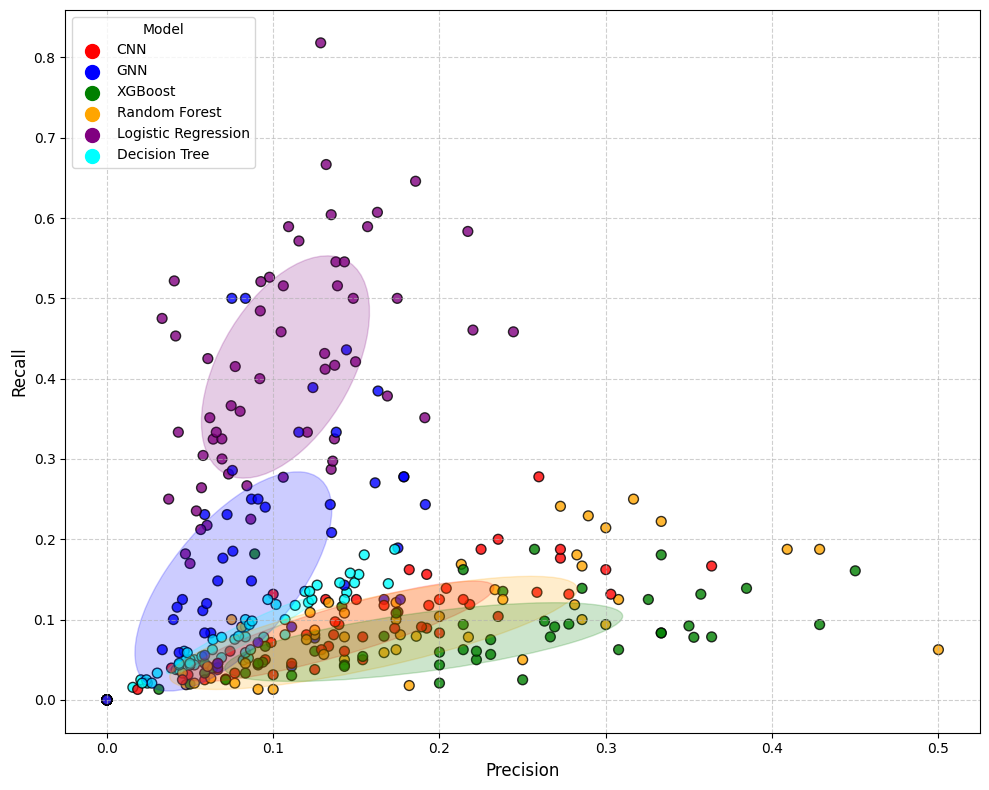

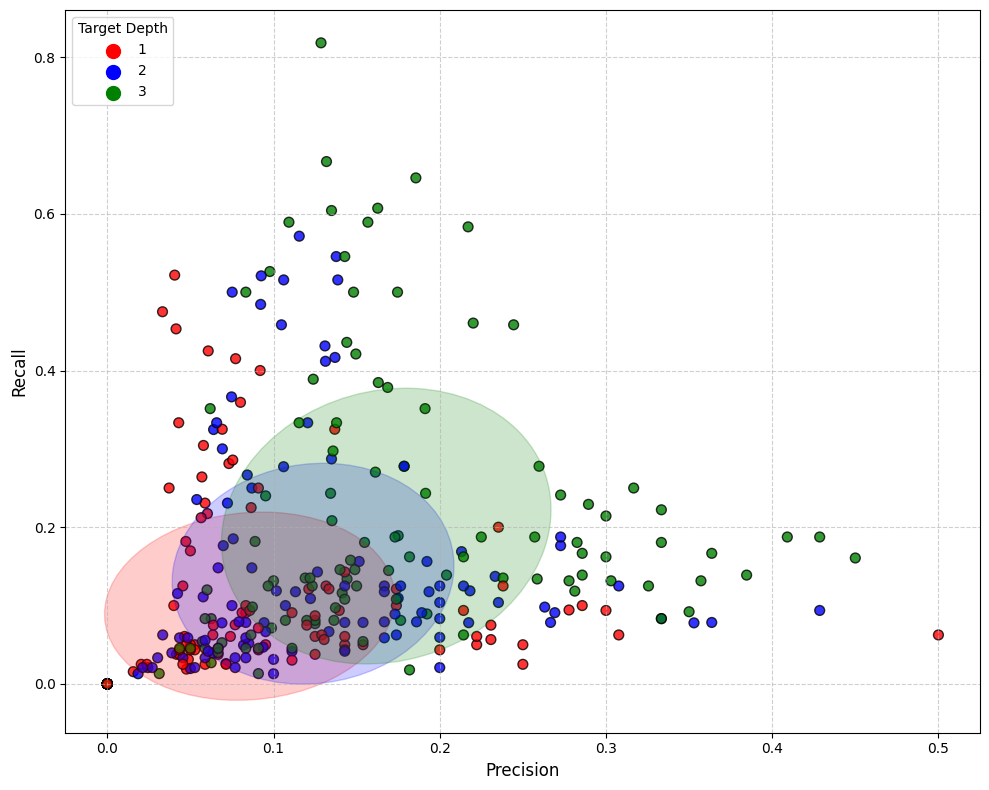

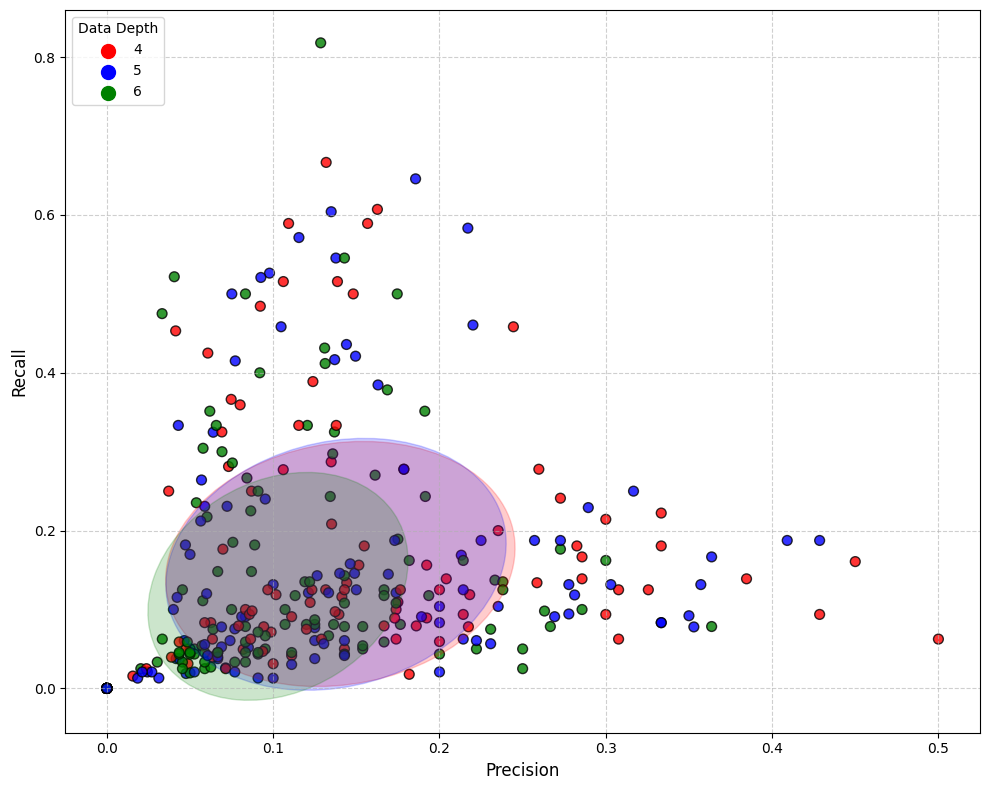

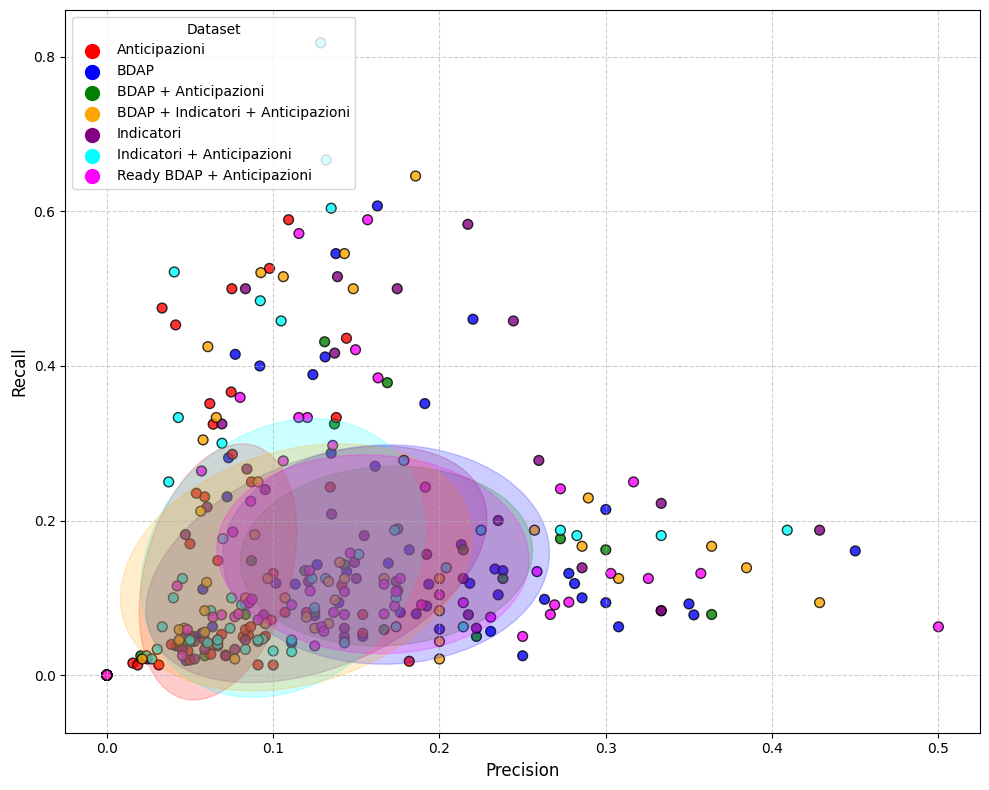

In [19]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['Model', 'Target Depth', 'Data Depth', 'Dataset']):

    if color_by == "model":
        unique_values = ['CNN', 'GNN', 'XGBoost', 'Random Forest', 'Logistic Regression', 'Decision Tree']
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(precision, recall, c=label_colors, s=50, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(precision)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((precision[i], recall[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("Precision", fontsize=12) 
    plt.ylabel("Recall", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_precision_recall_periodo{periodo}.png')
    plt.show()


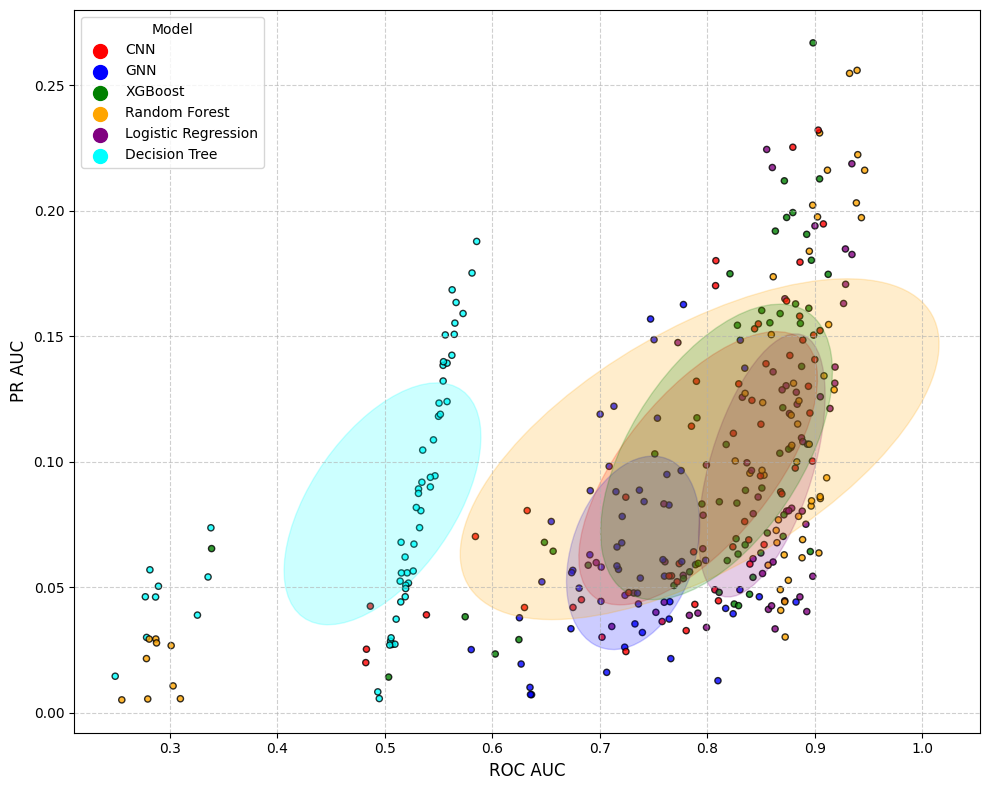

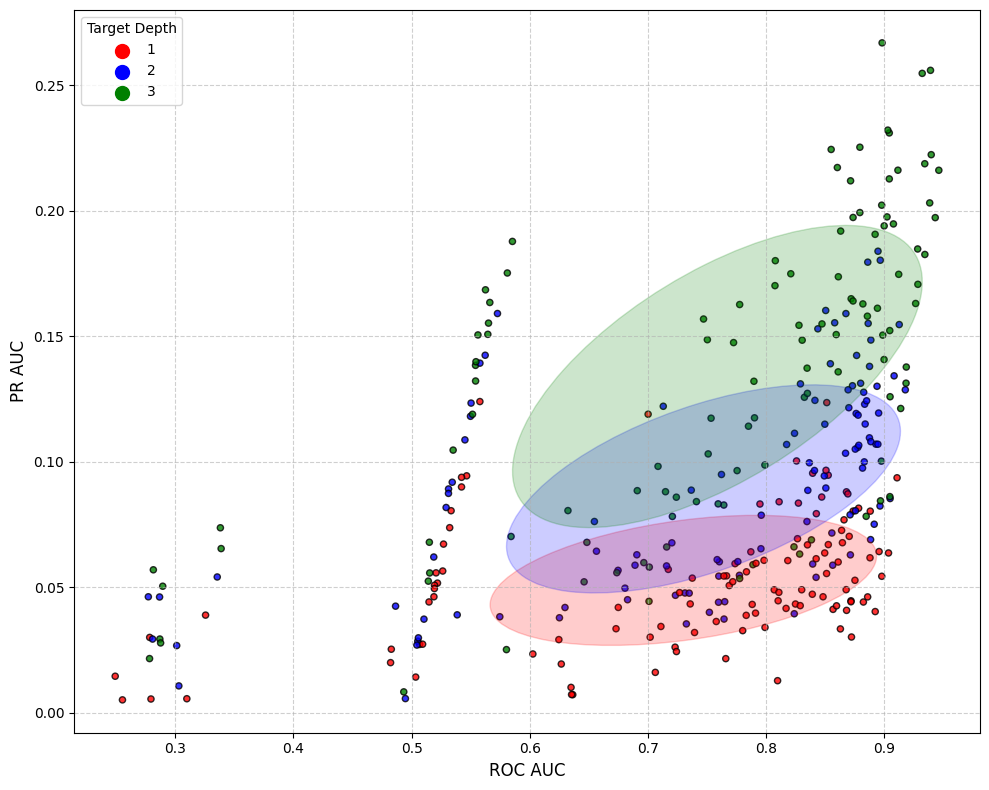

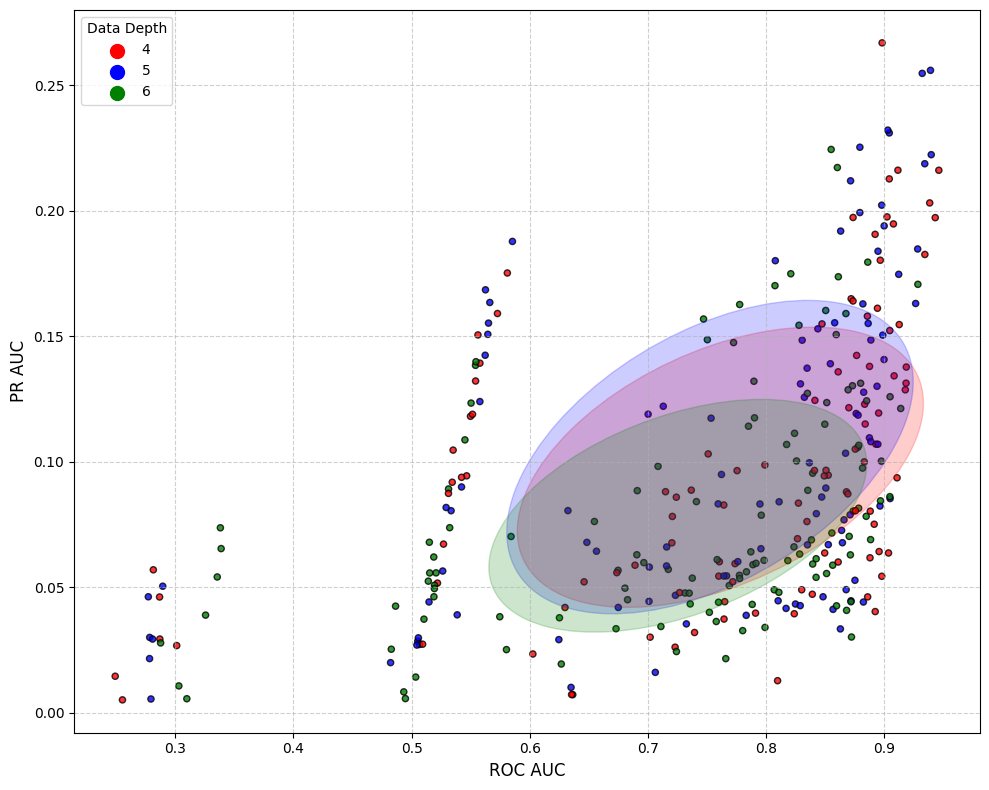

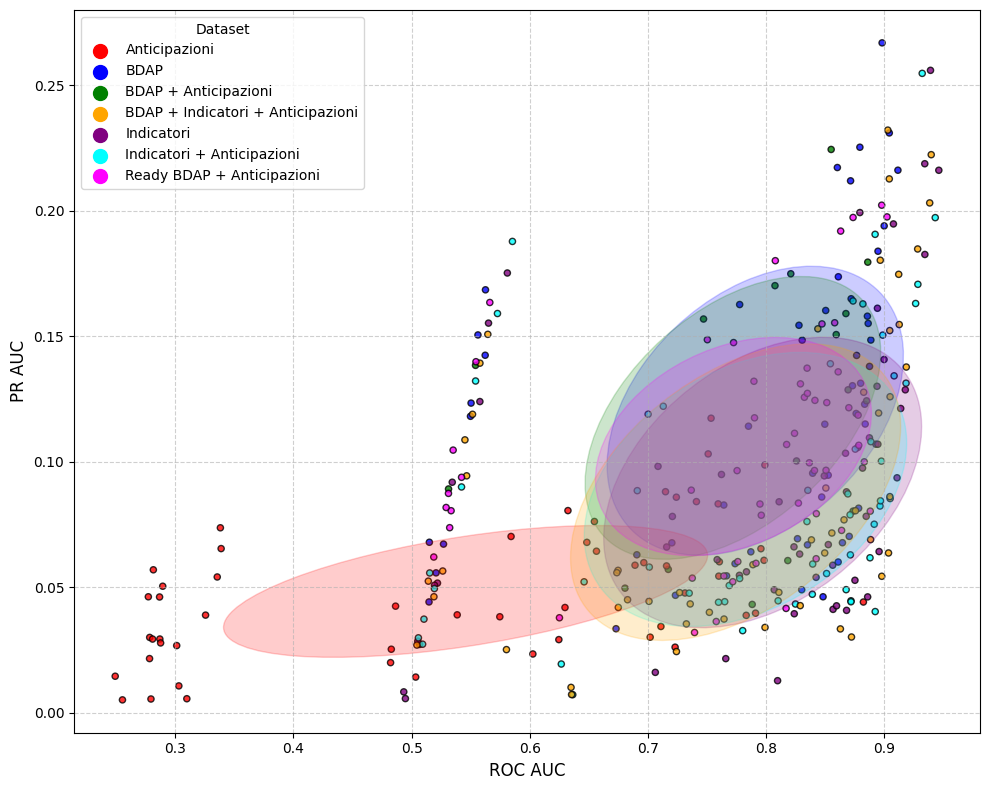

In [20]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['Model', 'Target Depth', 'Data Depth', 'Dataset']):

    if color_by == "model":
        unique_values = ['CNN', 'GNN', 'XGBoost', 'Random Forest', 'Logistic Regression', 'Decision Tree']
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(roc)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((roc[i], pr[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_periodo{periodo}.png')
    plt.show()

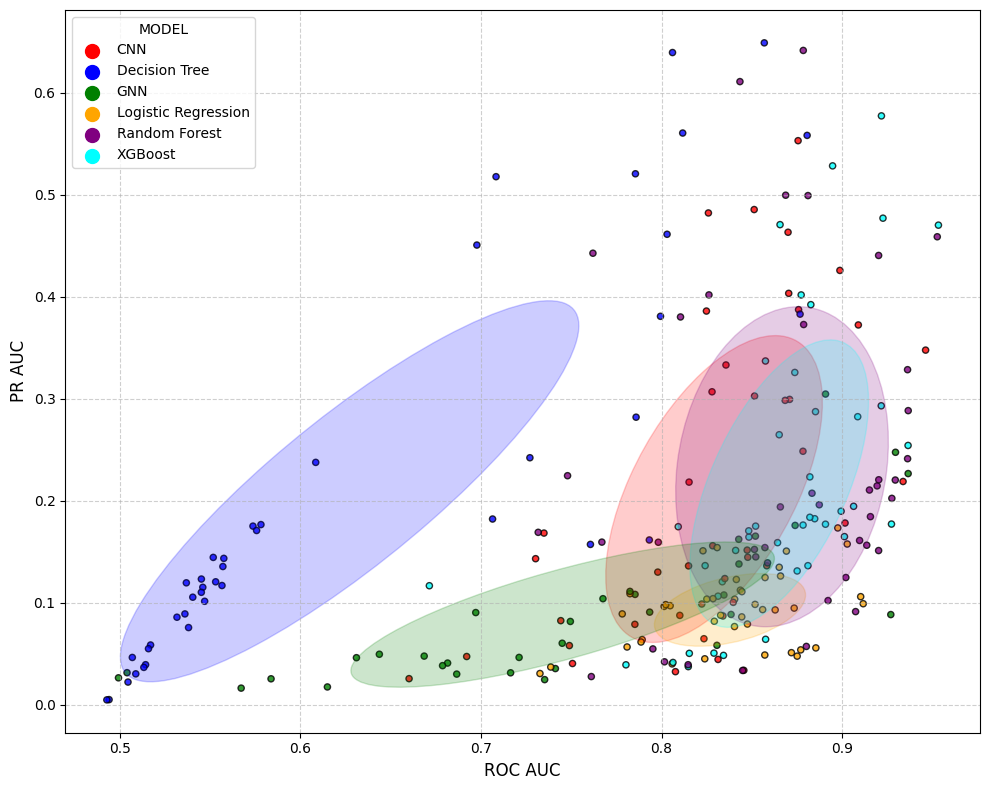

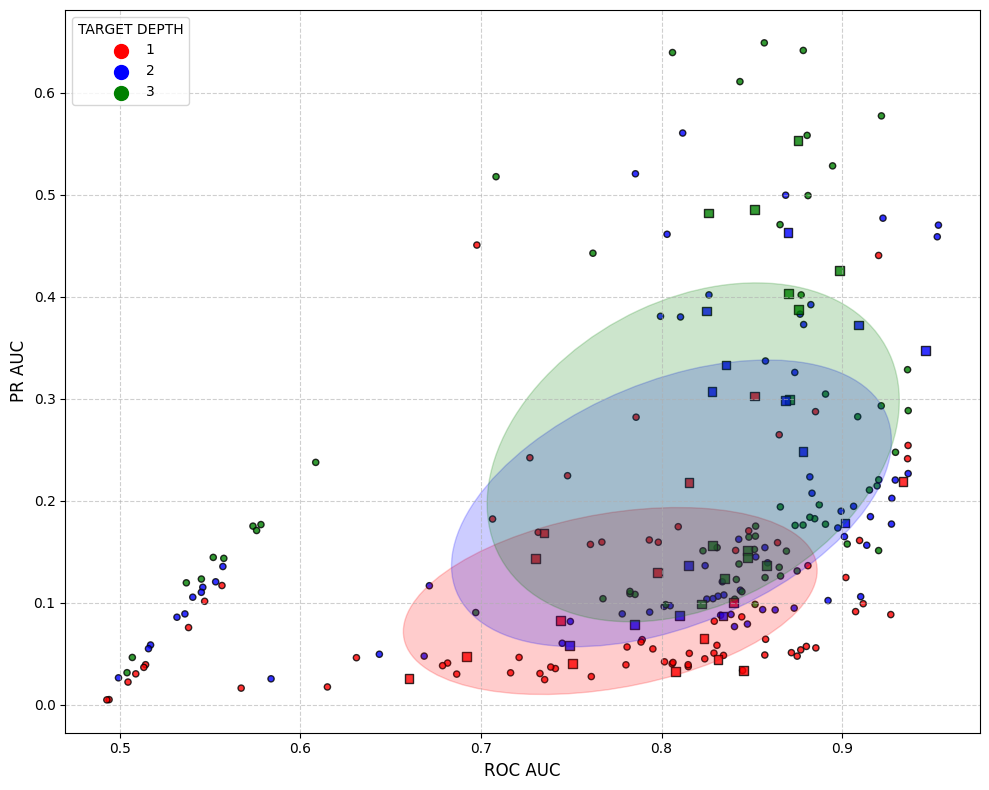

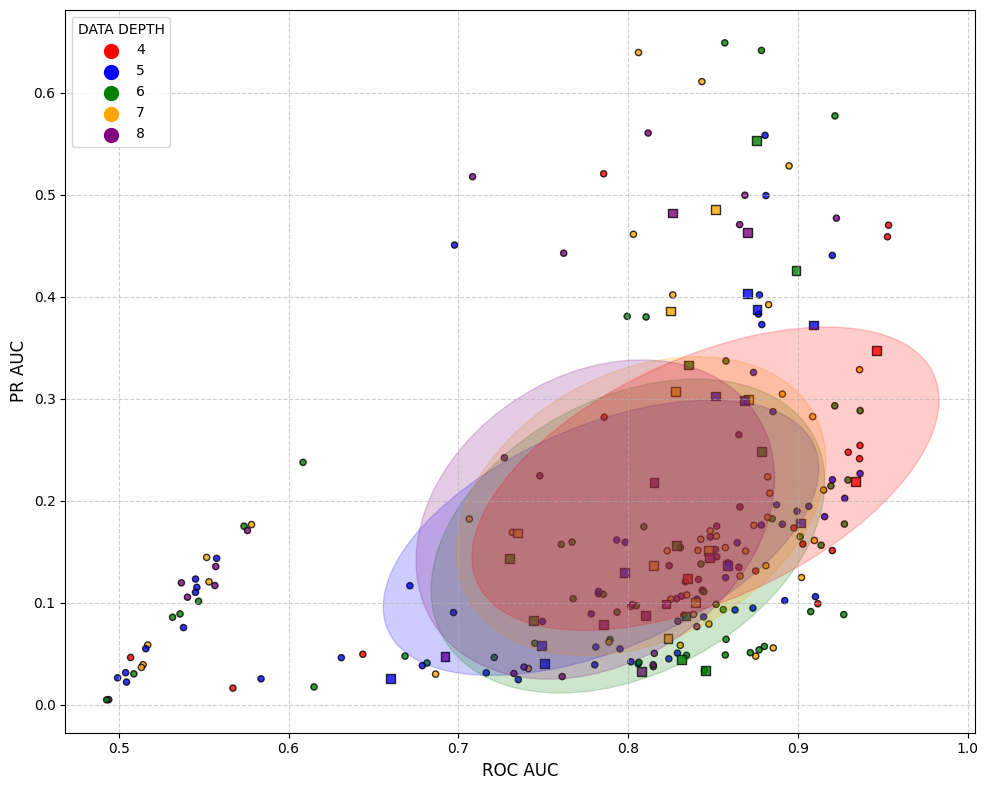

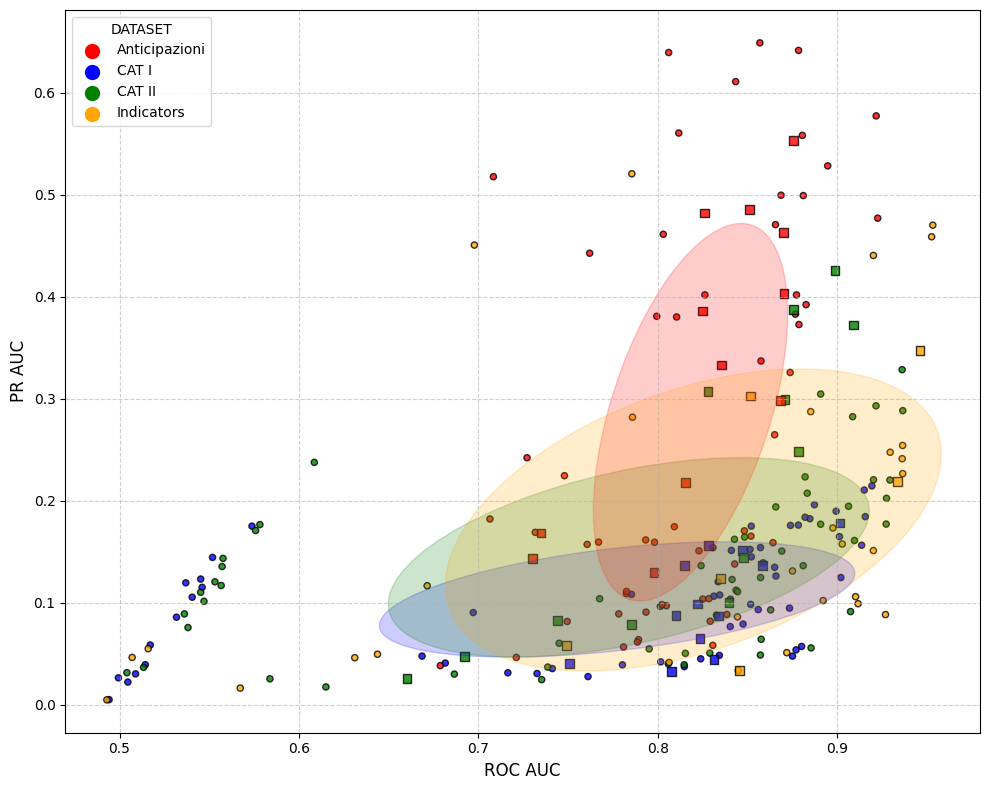

In [30]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = sorted(list(set(model)))
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))

    if color_by != "model":
        roc_cnn = []
        pr_cnn = []
        color_cnn = []

        roc_other = []
        pr_other = []
        color_other = []

        for i in range(len(model)):
            if model[i] == "CNN":
                roc_cnn.append(roc[i])
                pr_cnn.append(pr[i])
                color_cnn.append(label_colors[i])
            else:
                roc_other.append(roc[i])
                pr_other.append(pr[i])
                color_other.append(label_colors[i])

        # Plot non-CNN points as circles
        plt.scatter(roc_other, pr_other, c=color_other, s=20, edgecolor='k', alpha=0.8)

        # Plot CNN points as squares with correct color
        plt.scatter(roc_cnn, pr_cnn, c=color_cnn, s=40, marker='s', edgecolor='k', alpha=0.8)

    else:
        # If coloring by model, treat all equally
        plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(roc)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((roc[i], pr[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_ellips_squares.png')
    plt.show()

# MISC

In [3]:
comuni = pd.read_csv('data/comuni.csv', index_col='BDAP')
comuni_dismessi = pd.read_csv('data/comuni_dismessi.csv', index_col='BDAP')
comuni_nuovi = pd.read_csv('data/comuni_nuovi.csv', index_col='BDAP')

critici = pd.read_csv('data//CriticitàComuni.csv', sep = ';', encoding = 'latin_1', low_memory = False)
for year in np.arange(2000, 2025):
    comuni[f'Target {year}'] = 0
    comuni_dismessi[f'Target {year}'] = 0
    comuni_nuovi[f'Target {year}'] = 0
for year in np.arange(2000, 2025):
    for idx, row in critici.iterrows():
        if int(row['Anno']) == year:
            comune = row['Comune']
            comune_2 = comune.replace('-', ' ')
            comuni.loc[(comuni['Comune'] == f'COMUNE DI {comune}') | (comuni['Comune'] == f'COMUNE DI {comune_2}'), f'Target {year}'] = 1
            comuni_dismessi.loc[(comuni_dismessi['Comune'] == f'COMUNE DI {comune}') | (comuni_dismessi['Comune'] == f'COMUNE DI {comune_2}'), f'Target {year}'] = 1
            comuni_nuovi.loc[(comuni_nuovi['Comune'] == f'COMUNE DI {comune}') | (comuni_nuovi['Comune'] == f'COMUNE DI {comune_2}'), f'Target {year}'] = 1

In [16]:
# Compute statistics on Target 1s across years for each dataframe

target_years = [f'Target {year}' for year in np.arange(2000, 2025)]

# Count 1s for each year in each dataframe
stats_comuni = {year: comuni[year].sum() for year in target_years}
stats_comuni_dismessi = {year: comuni_dismessi[year].sum() for year in target_years}
stats_comuni_nuovi = {year: comuni_nuovi[year].sum() for year in target_years}

# Total number of municipalities in each dataframe
summary_totals = pd.Series({
    'comuni': len(comuni),
    'comuni_dismessi': len(comuni_dismessi),
    'comuni_nuovi': len(comuni_nuovi),
}, name='total_comuni')

# Create summary dataframe with counts
summary_targets = pd.DataFrame({
    'comuni': stats_comuni,
    'comuni_dismessi': stats_comuni_dismessi,
    'comuni_nuovi': stats_comuni_nuovi
})

# Calculate percentages over each dataframe total
pct_comuni = {year: (comuni[year].sum() / len(comuni)) * 100 for year in target_years}
pct_comuni_dismessi = {year: (comuni_dismessi[year].sum() / len(comuni_dismessi)) * 100 for year in target_years}
pct_comuni_nuovi = {year: (comuni_nuovi[year].sum() / len(comuni_nuovi)) * 100 for year in target_years}

summary_targets_pct = pd.DataFrame({
    'comuni_%': pct_comuni,
    'comuni_dismessi_%': pct_comuni_dismessi,
    'comuni_nuovi_%': pct_comuni_nuovi
})

print('Total municipalities in each dataframe:')
print(summary_totals)
print('\nNumber of critical cases (1s) by year:')
print(summary_targets)
print('\nPercentage of critical cases (1s) by year:')
print(summary_targets_pct.round(2))
print('\n=== Summary Statistics ===')
print(f"comuni: total={summary_targets['comuni'].sum()}, mean={summary_targets['comuni'].mean():.2f}, std={summary_targets['comuni'].std():.2f}, min={summary_targets['comuni'].min():.0f}, max={summary_targets['comuni'].max():.0f}")
print(f"comuni_dismessi: total={summary_targets['comuni_dismessi'].sum()}, mean={summary_targets['comuni_dismessi'].mean():.2f}, std={summary_targets['comuni_dismessi'].std():.2f}, min={summary_targets['comuni_dismessi'].min():.0f}, max={summary_targets['comuni_dismessi'].max():.0f}")
print(f"comuni_nuovi: total={summary_targets['comuni_nuovi'].sum()}, mean={summary_targets['comuni_nuovi'].mean():.2f}, std={summary_targets['comuni_nuovi'].std():.2f}, min={summary_targets['comuni_nuovi'].min():.0f}, max={summary_targets['comuni_nuovi'].max():.0f}")
print(f"\ncomuni_%: mean={summary_targets_pct['comuni_%'].mean():.2f}%, min={summary_targets_pct['comuni_%'].min():.2f}%, max={summary_targets_pct['comuni_%'].max():.2f}%")
print(f"comuni_dismessi_%: mean={summary_targets_pct['comuni_dismessi_%'].mean():.2f}%, min={summary_targets_pct['comuni_dismessi_%'].min():.2f}%, max={summary_targets_pct['comuni_dismessi_%'].max():.2f}%")
print(f"comuni_nuovi_%: mean={summary_targets_pct['comuni_nuovi_%'].mean():.2f}%, min={summary_targets_pct['comuni_nuovi_%'].min():.2f}%, max={summary_targets_pct['comuni_nuovi_%'].max():.2f}%")

Total municipalities in each dataframe:
comuni             7773
comuni_dismessi     173
comuni_nuovi        124
Name: total_comuni, dtype: int64

Number of critical cases (1s) by year:
             comuni  comuni_dismessi  comuni_nuovi
Target 2000       0                0             0
Target 2001       4                0             0
Target 2002       2                0             0
Target 2003       2                0             0
Target 2004       2                0             0
Target 2005       4                0             0
Target 2006       3                0             0
Target 2007       1                0             0
Target 2008       6                0             0
Target 2009       6                0             0
Target 2010       5                0             0
Target 2011      13                0             0
Target 2012      62                0             0
Target 2013      80                0             0
Target 2014      65                1             0

In [17]:
# Count municipalities experiencing distress in multiple years across 2000-2025

target_years = [f'Target {year}' for year in np.arange(2000, 2025)]

# Union of all municipality indices
all_idx = sorted(set(comuni.index) | set(comuni_dismessi.index) | set(comuni_nuovi.index))

# Reindex and ensure integer 0/1 values
c1 = comuni.reindex(all_idx)[target_years].fillna(0).astype(int)
c2 = comuni_dismessi.reindex(all_idx)[target_years].fillna(0).astype(int)
c3 = comuni_nuovi.reindex(all_idx)[target_years].fillna(0).astype(int)

# For each year, mark 1 if any dataframe has a 1 (avoid double-counting same year across dfs)
combined_yearly = ((c1 == 1) | (c2 == 1) | (c3 == 1)).astype(int)

# Number of distinct years with distress per municipality
years_with_distress = combined_yearly.sum(axis=1)

# Distribution: how many municipalities had 0,1,2,3,... distressed years
dist_counts = years_with_distress.value_counts().sort_index()
dist_pct = (dist_counts / len(years_with_distress) * 100).round(2)

summary_df = pd.DataFrame({'count': dist_counts, 'pct': dist_pct})
summary_df.index.name = 'years_with_distress'

print(f"Total municipalities considered: {len(years_with_distress)}\n")
print("Distribution of distinct distress years per municipality (2000-2024):")
print(summary_df)

# Number and percentage of municipalities with multiple distress (>=2 years)
multi_count = dist_counts[dist_counts.index >= 2].sum() if any(dist_counts.index >= 2) else 0
multi_pct = (multi_count / len(years_with_distress) * 100) if len(years_with_distress) > 0 else 0
print(f"\nMunicipalities with distress in >=2 distinct years: {multi_count} ({multi_pct:.2f}%)")

# Optional: show examples names (first 10 municipalities with highest number of distressed years)
examples = comuni.loc[years_with_distress.sort_values(ascending=False).head(3).index, 'Comune'].values
print("\nTop 10 municipalities by number of distinct distressed years:")
for elem in examples:
    print(elem)


Total municipalities considered: 8069

Distribution of distinct distress years per municipality (2000-2024):
                     count    pct
years_with_distress              
0                     7367  91.30
1                      503   6.23
2                      167   2.07
3                       29   0.36
4                        3   0.04

Municipalities with distress in >=2 distinct years: 199 (2.47%)

Top 10 municipalities by number of distinct distressed years:
COMUNE DI TAORMINA
COMUNE DI SCORDIA
COMUNE DI PALAGONIA


In [18]:
# Calculate mean time between consecutive distress events for municipalities with multiple distress years

# Get target year columns
target_cols = [f'Target {year}' for year in np.arange(2000, 2025)]

# List to store time gaps between consecutive distress years
all_gaps = []

# Iterate through municipalities with >=2 distress years
for idx, row in combined_yearly.iterrows():
    # Get years where distress occurred (1s)
    distress_years = combined_yearly.loc[idx][combined_yearly.loc[idx] == 1].index.tolist()
    
    if len(distress_years) >= 2:
        # Extract year numbers from column names
        distress_year_nums = [int(col.split()[1]) for col in distress_years]
        distress_year_nums.sort()
        
        # Calculate gaps between consecutive distress years
        gaps = [distress_year_nums[i+1] - distress_year_nums[i] for i in range(len(distress_year_nums)-1)]
        all_gaps.extend(gaps)

# Calculate statistics on gaps
if all_gaps:
    mean_gap = np.mean(all_gaps)
    median_gap = np.median(all_gaps)
    std_gap = np.std(all_gaps)
    min_gap = np.min(all_gaps)
    max_gap = np.max(all_gaps)
    
    print(f"\n=== Mean Time Between Multiple Distress Events ===")
    print(f"Mean gap between consecutive distress years: {mean_gap:.2f} years")
    print(f"Median gap: {median_gap:.2f} years")
    print(f"Std dev: {std_gap:.2f} years")
    print(f"Min gap: {min_gap} years")
    print(f"Max gap: {max_gap} years")
    print(f"Total number of gaps analyzed: {len(all_gaps)}")
else:
    print("No municipalities with multiple distress years found.")



=== Mean Time Between Multiple Distress Events ===
Mean gap between consecutive distress years: 3.46 years
Median gap: 2.00 years
Std dev: 3.07 years
Min gap: 1 years
Max gap: 19 years
Total number of gaps analyzed: 234
